# Predicting Top 10% E. coli Inhibition Using Assay-Informed and Molecular Features

### Priscilla Vaskez · Trinity Ho · Yasemin Sucu · Dongwan Kim

## Objective

We classify whether a compound belongs to the top 10% of *E. coli* inhibition based on `INHIB_AVE`. This final notebook is not a structure-only model. It is an assay-informed classification model that starts from the processed master dataframe, then adds stronger feature engineering using assay-context features, RDKit descriptors, MACCS keys, 2048-bit Morgan fingerprints, and Tanimoto similarity to top 10% inhibition features computed from those Morgan fingerprints.

This notebook builds on the trial-and-error from the earlier notebooks. The regression, SVM, GLM/logistic regression, ANN, and clustering experiments helped show which parts of the problem were difficult: exact-value regression was noisy, raw accuracy was misleading under class imbalance, and simpler logistic/GLM models did not capture the high-inhibition class well enough. Based on those results, we added more targeted engineered features and stronger regularization in the final model rather than simply repeating the same logistic regression setup.

The main goal is to see whether this expanded feature set can identify highly active compounds better. Since raw accuracy can be misleading for an imbalanced top-10% classification problem, we focus more on `precision`, `recall`, `F1`, and `ROC-AUC`, especially for the high-inhibition class.

---
## Load Libraries

In [1]:
import re
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, MACCSkeys, rdFingerprintGenerator
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


---
## Load Data

We use the merged E. coli master CSV created from the main preprocessing notebook. The binary target is based on `INHIB_AVE`. Compounds above the 90th percentile are labeled as `1`.
All others are labeled as `0`.

In [2]:
master_df = pd.read_csv("ecoli_merged_master_4268.csv")

y = master_df["INHIB_AVE"]
inhib_std = master_df["INHIB_STD"].astype(float)

# Top 10% positive class (`INHIB_AVE` above the 90th percentile).
top10_cutoff = y.quantile(0.90)
y_top10 = (y > top10_cutoff).astype(int) # binary label: 1 = top 10%, 0 = bottom 90%

print("master_df shape:", master_df.shape)
print("Top 10% cutoff (INHIB_AVE):", round(top10_cutoff, 2))
print("Positive (top 10%) count:", int(y_top10.sum()))
print("Positive rate:", round(y_top10.mean(), 5))

master_df shape: (4268, 27)
Top 10% cutoff (INHIB_AVE): 30.92
Positive (top 10%) count: 427
Positive rate: 0.10005


---
# EDA

We first check the `INHIB_AVE` distribution and compare several possible cutoffs. This helps us see how strict each label definition would be and how many borderline compounds may have unstable labels.

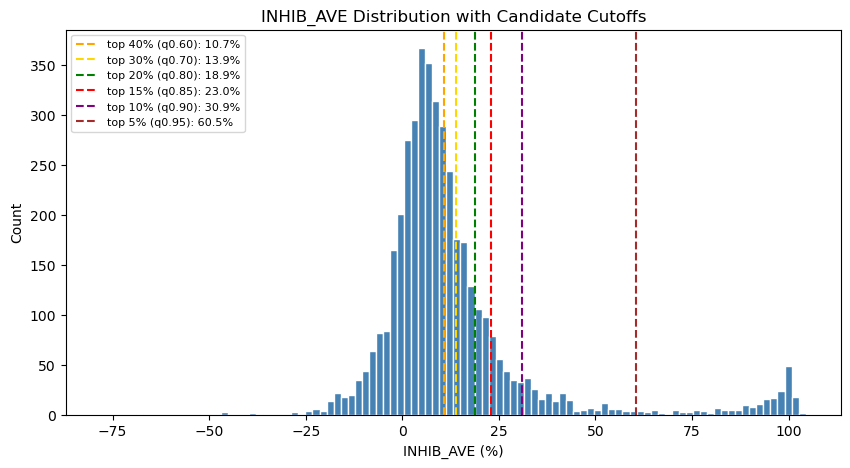

In [3]:
# Compare several possible cutoffs
cutoff_grid = {
    "top 40% (q0.60)": y.quantile(0.60),
    "top 30% (q0.70)": y.quantile(0.70),
    "top 20% (q0.80)": y.quantile(0.80),
    "top 15% (q0.85)": y.quantile(0.85),
    "top 10% (q0.90)": y.quantile(0.90),
    "top 5% (q0.95)": y.quantile(0.95)
}

line_colors = ["orange", "gold", "green", "red", "purple", "brown"]

plt.figure(figsize=(10, 5))
plt.hist(y.dropna(), bins=100, color="steelblue", edgecolor="white")

for label, val, color in zip(cutoff_grid.keys(), cutoff_grid.values(), line_colors):
    plt.axvline(val, color=color, linestyle="--", linewidth=1.5, label=f"{label}: {val:.1f}%")

plt.xlabel("INHIB_AVE (%)")
plt.ylabel("Count")
plt.title("INHIB_AVE Distribution with Candidate Cutoffs")
plt.legend(fontsize=8, loc="upper left")
plt.show()

The distribution is right-skewed. We tested several percentile-based cutoffs before choosing the final top-10% label. This also helps us estimate how many compounds may fall near the decision boundary.

## Buffer Filter Check

We estimate how many rows would be considered borderline near each cutoff. Rows close to the cutoff relative to `INHIB_STD` may have unstable labels.

In [4]:
# Buffer filter drop-rate estimate per cutoff
BUFFER_K = 1.5

cutoff_summary = []

for label, cutoff_val in cutoff_grid.items():
    in_buffer = (master_df["INHIB_AVE"] - cutoff_val).abs() < BUFFER_K * master_df["INHIB_STD"]
    cutoff_summary.append({
        "cutoff": label,
        "threshold": round(cutoff_val, 1),
        "buffer_drop": f"{in_buffer.mean():.1%}"
    })

pd.DataFrame(cutoff_summary)

,cutoff,threshold,buffer_drop
0,top 40% (q0.60),10.7,30.7%
1,top 30% (q0.70),13.9,24.5%
2,top 20% (q0.80),18.9,16.2%
3,top 15% (q0.85),23.0,11.2%
4,top 10% (q0.90),30.9,5.4%
5,top 5% (q0.95),60.5,1.2%


---
## Chemistry Space Check

We use Morgan fingerprints and UMAP to visualize the chemical space of the dataset. The goal is to see whether top-10% compounds form a clear local pocket or remain spread across the broader library.Here, the comparison is between the top 10% and the remaining 90%, not active vs inactive.

Morgan fingerprint matrix shape: (4268, 2048)


/opt/anaconda3/envs/chem277a-project2/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/anaconda3/envs/chem277a-project2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


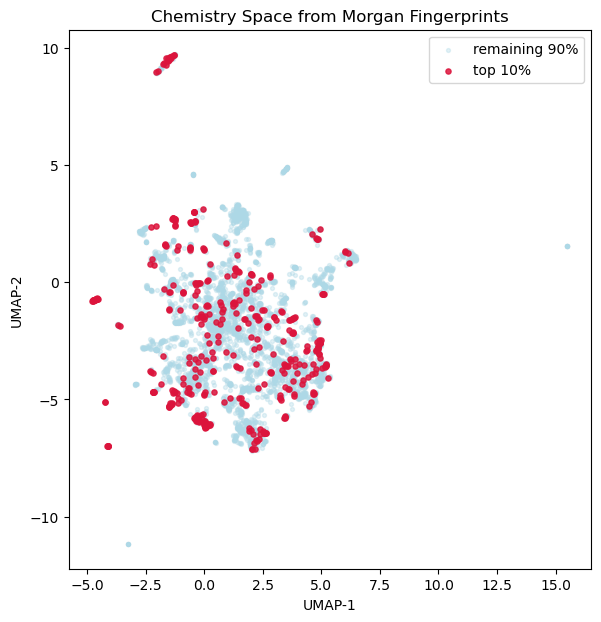

In [5]:
# Morgan fingerprint -> UMAP 2D

# 2048-bit Morgan fingerprint
mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
mols = master_df["SMILES"].apply(Chem.MolFromSmiles)

X_fp = np.array([list(mfp_gen.GetFingerprint(m)) for m in mols])
labels = y_top10.values

print("Morgan fingerprint matrix shape:", X_fp.shape)

# UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="jaccard",
    random_state=28
)

X_umap = umap_model.fit_transform(X_fp)

# Plot
plt.figure(figsize=(8, 7))

plt.scatter(
    X_umap[labels == 0, 0],
    X_umap[labels == 0, 1],
    s=8,
    alpha=0.35,
    color="lightblue",
    label="remaining 90%"
)

plt.scatter(
    X_umap[labels == 1, 0],
    X_umap[labels == 1, 1],
    s=14,
    alpha=0.85,
    color="crimson",
    label="top 10%"
)

ax = plt.gca()
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("Chemistry Space from Morgan Fingerprints")
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.show()

One small region looks enriched in top-10% compounds. To check this more clearly, we run KMeans on the UMAP embedding and compare the top-10% fraction in each cluster.

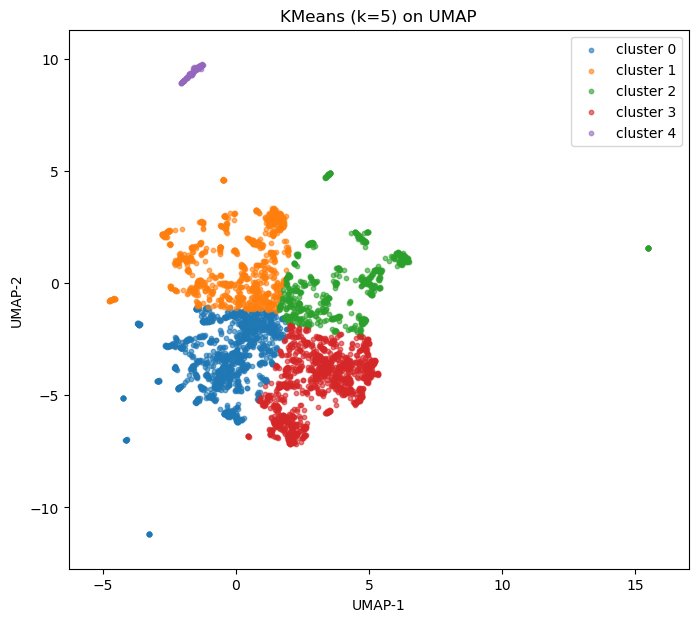

In [6]:
# KMeans on UMAP

K = 5
kmeans = KMeans(n_clusters=K, random_state=28, n_init=10)
clusters = kmeans.fit_predict(X_umap)

fig, ax = plt.subplots(figsize=(8, 7))

for k in range(K):
    mask = clusters == k
    ax.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        s=10,
        alpha=0.6,
        label=f"cluster {k}",
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title(f"KMeans (k={K}) on UMAP")
ax.legend()

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.set_xlim(x_min - 0.5, x_max + 0.5)
ax.set_ylim(y_min - 0.5, y_max + 0.5)

plt.show()

The cluster summary shows one small chemistry pocket enriched in top-10% compounds, while most clusters stay close to the overall baseline. This suggests that coarse chemistry grouping captures part of the signal, but not most of it. So the main prediction task likely depends on finer-grained molecular features and assay-context information.

---
## Train / validation / test split

We first make a stratified train/test split.

Then we split the training side again into:
- model-training
- validation

The test set is kept untouched until final evaluation.

We also remove `INHIB_AVE` and `INHIB_STD` from the feature table before modeling.
These are kept separately because the buffer filter still uses them on the model-training rows.

In [7]:
# Stratified train / validation / test split

features_df = master_df.drop(columns=["INHIB_AVE", "INHIB_STD"])

train_idx, test_idx = train_test_split(master_df.index, test_size=0.2, stratify=y_top10, random_state=28)

train_model_idx, validation_idx = train_test_split(train_idx, test_size=0.2, stratify=y_top10.loc[train_idx], random_state=28)

train_idx = pd.Index(train_idx)
test_idx = pd.Index(test_idx)
train_model_idx = pd.Index(train_model_idx)
validation_idx = pd.Index(validation_idx)

print(f"Train model: {len(train_model_idx)} rows  ({y_top10.loc[train_model_idx].mean():.1%} active)")
print(f"Validation:  {len(validation_idx)} rows  ({y_top10.loc[validation_idx].mean():.1%} active)")
print(f"Test:        {len(test_idx)} rows  ({y_top10.loc[test_idx].mean():.1%} active)")

Train model: 2731 rows  (10.0% active)
Validation:  683 rows  (10.0% active)
Test:        854 rows  (10.0% active)


---
## Buffer filter on model-training rows

The binary label is defined by a hard cutoff at the 90th percentile of `INHIB_AVE` (about 30.9%). Compounds whose measured value falls within the experimental uncertainty (`INHIB_STD`) of this cutoff can have unstable labels. Even a small fluctuation in the underlying measurement could flip them between the top-10% class and the rest. Training on these borderline rows would teach the model a decision rule built partly on measurement noise.

We drop model-training rows where `|INHIB_AVE - cutoff| < 1.5 × INHIB_STD`. The factor `BUFFER_K = 1.5` is wide enough to remove the genuinely ambiguous cases while still preserving most of the data. The filter is applied to model-training rows only. Validation and test rows stay untouched so the evaluation still reflects performance on the full, unfiltered distribution.

In [8]:
# Buffer filter on model-training rows

BUFFER_K = 1.5

distance_from_cutoff = (y - top10_cutoff).abs()
buffer_width = BUFFER_K * inhib_std.fillna(0.0)
in_buffer_full = distance_from_cutoff < buffer_width

ambiguous_train_idx = train_model_idx.intersection(master_df.index[in_buffer_full])
train_model_idx_clean = train_model_idx.difference(ambiguous_train_idx)

drop_rate = len(ambiguous_train_idx) / len(train_model_idx)

print(f"After buffer: {len(train_model_idx_clean)} rows ({y_top10.loc[train_model_idx_clean].mean():.1%} top 10%)")
print(f"Dropped: {len(ambiguous_train_idx)} rows ({drop_rate:.1%})")
print(f"Validation untouched: {len(validation_idx)} rows")
print(f"Test untouched: {len(test_idx)} rows")

After buffer: 2598 rows (8.7% top 10%)
Dropped: 133 rows (4.9%)
Validation untouched: 683 rows
Test untouched: 854 rows


---

## Feature matrix construction

We assemble a 2,447-dimensional feature representation that combines four main sources of chemical and experimental signal.

The first block is **assay-context numeric features**: `DMAX_AVE`, `MIC_VALUE_uM`, and `CONC_VALUE_uM`. These capture the dose-response context of each measurement and were already highly informative in our earlier regression analysis. The second block is categorical assay metadata one-hot encoded from `STRAIN` and `MIC_OPERATOR`. The latter is especially useful because censored MIC values with the `>` operator carry distinct information about weakly inhibitory or non-top-10% compounds.

The third block consists of **chemistry features computed from SMILES**: 210 RDKit descriptors covering physicochemical properties such as logP, TPSA, HBA/HBD counts, and ring counts, 160 MACCS keys encoding standardized substructural patterns, and 2,048-bit Morgan fingerprints with radius 2 that capture local atomic environments at fine resolution. The fourth block is **20 Tanimoto similarity features** computed against the top-10% set on the training partition only. These features measure how chemically similar each compound is to known top-10% compounds using Morgan and MACCS fingerprints. Computing these similarity features on the training set only, rather than the full dataset, helps prevent test-set information from leaking back into the training representation.

We keep all four blocks and let elastic net regularization handle redundancy during training instead of manually removing features ahead of time. This lets the model decide which signals are most informative.

In [9]:
# Feature matrix construction

# Tanimoto reference indices from cleaned model-training rows
top10_train_idx = train_model_idx_clean[y_top10.loc[train_model_idx_clean].eq(1)].tolist()
remaining90_train_idx = train_model_idx_clean[y_top10.loc[train_model_idx_clean].eq(0)].tolist()

# 1. Assay numeric features ------------------
def parse_conc(s):
    nums = re.findall(r"\d+\.?\d*", str(s))
    return float(nums[0]) if nums else np.nan


def conc_to_uM(row):
    s = str(row["CONC"])
    val = parse_conc(s)

    if pd.isna(val):
        return np.nan
    if "uM" in s:
        return val
    if "ug/mL" in s:
        return val * 1000 / row["MW"]

    return np.nan


conc_uM = master_df.apply(conc_to_uM, axis=1)

X_numeric = pd.DataFrame(
    {
        "DMAX_AVE": master_df["DMAX_AVE"],
        "MIC_VALUE_uM": master_df["MIC_VALUE_uM"],
        "CONC_VALUE_uM": conc_uM,
    },
    index=master_df.index
)

# 2. Assay categorical features ------------------
X_categorical = pd.get_dummies(
    master_df[["STRAIN", "MIC_OPERATOR"]].astype(str),
    prefix=["STRAIN", "MIC_OPERATOR"],
    drop_first=False
).astype(int)

# 3. RDKit descriptors ------------------
mols = master_df["SMILES"].apply(Chem.MolFromSmiles)


def compute_rdkit_descriptors(mol):
    return {
        f"rdkit_{name}": func(mol) if mol is not None else np.nan
        for name, func in Descriptors._descList
    }


X_rdkit = pd.DataFrame(
    [compute_rdkit_descriptors(mol) for mol in mols],
    index=master_df.index,
).replace([np.inf, -np.inf], np.nan)

X_rdkit = X_rdkit.dropna(axis=1, how="all")
X_rdkit = X_rdkit.loc[:, X_rdkit.nunique(dropna=True) > 1]

# 4. MACCS keys ------------------
def fp_to_array(fp, n_bits, skip_first=False):
    arr = np.zeros(n_bits, dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr[1:] if skip_first else arr


maccs_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in mols]

X_maccs = pd.DataFrame(
    [fp_to_array(fp, 167, skip_first=True) for fp in maccs_fps],
    index=master_df.index,
    columns=[f"maccs_{i}" for i in range(1, 167)],
)

X_maccs = X_maccs.loc[:, X_maccs.nunique() > 1]

# 5. Morgan fingerprints ------------------
mfp_gen = GetMorganGenerator(radius=2, fpSize=2048)
morgan_fps = [mfp_gen.GetFingerprint(mol) for mol in mols]

X_morgan = pd.DataFrame(
    [fp_to_array(fp, 2048) for fp in morgan_fps],
    index=master_df.index,
    columns=[f"morgan_r2_{i}" for i in range(2048)],
)

# 6. Tanimoto similarity features ------------------
def top_k_mean(values, k):
    return np.sort(values)[::-1][:k].mean() if len(values) >= 1 else np.nan


def tanimoto_features(fps, ref_indices, prefix):
    ref_pairs = [(i, fps[i]) for i in ref_indices if fps[i] is not None]

    rows = []
    cols = [f"{prefix}_{stat}" for stat in ["max", "mean", "top5_mean", "top10_mean", "count_ge_0_50"]]

    for idx in master_df.index:
        fp = fps[idx]
        valid_refs = [rfp for ri, rfp in ref_pairs if ri != idx]

        if fp is None or not valid_refs:
            rows.append({c: np.nan for c in cols})
            continue

        similarity_scores = np.array(DataStructs.BulkTanimotoSimilarity(fp, valid_refs))

        rows.append(
            {
                cols[0]: similarity_scores.max(),
                cols[1]: similarity_scores.mean(),
                cols[2]: top_k_mean(similarity_scores, 5),
                cols[3]: top_k_mean(similarity_scores, 10),
                cols[4]: int((similarity_scores >= 0.50).sum()),
            }
        )

    return pd.DataFrame(rows, index=master_df.index)


X_tanimoto = pd.concat(
    [
        tanimoto_features(morgan_fps, top10_train_idx, "tan_morgan_top10"),
        tanimoto_features(morgan_fps, remaining90_train_idx, "tan_morgan_remaining90"),
        tanimoto_features(maccs_fps, top10_train_idx, "tan_maccs_top10"),
        tanimoto_features(maccs_fps, remaining90_train_idx, "tan_maccs_remaining90"),
    ],
    axis=1,
)

# Combine feature blocks ------------------
X_full = pd.concat([X_numeric, X_categorical, X_rdkit, X_maccs, X_morgan, X_tanimoto], axis=1)

X_train = X_full.loc[train_model_idx_clean]
X_validation = X_full.loc[validation_idx]
X_test = X_full.loc[test_idx]

y_train = y_top10.loc[train_model_idx_clean]
y_validation = y_top10.loc[validation_idx]
y_test = y_top10.loc[test_idx]

print("Numeric:", X_numeric.shape)
print("Categorical:", X_categorical.shape)
print("RDKit:", X_rdkit.shape)
print("MACCS:", X_maccs.shape)
print("Morgan:", X_morgan.shape)
print("Tanimoto:", X_tanimoto.shape)
print("X_full:", X_full.shape)
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

Numeric: (4268, 3)
Categorical: (4268, 6)
RDKit: (4268, 210)
MACCS: (4268, 160)
Morgan: (4268, 2048)
Tanimoto: (4268, 20)
X_full: (4268, 2447)
X_train: (2598, 2447)
X_validation: (683, 2447)
X_test: (854, 2447)


---
## Handling missing values

A small number of RDKit descriptors fail for some compounds. Most of these come from BCUT2D descriptors and partial-charge-related features. Before choosing an imputation strategy, we first check how much missingness exists in the training feature matrix. Since the missing rate is very small, replacing with median is enough here.

In [10]:
# NaN diagnostic

nan_per_col = X_train.isna().sum()
cols_with_nan = (nan_per_col > 0).sum()
total_nan = nan_per_col.sum()
total_cells = X_train.size

print("Columns with any NaN:", cols_with_nan, "/", X_train.shape[1])
print("Total NaN cells:", total_nan, "/", total_cells, f"({total_nan / total_cells:.3%})")
print()
print("Top 10 columns by NaN count:")

nan_per_col[nan_per_col > 0].sort_values(ascending=False).head(10)

Columns with any NaN: 12 / 2447
Total NaN cells: 408 / 6357306 (0.006%)

Top 10 columns by NaN count:


rdkit_BCUT2D_MWHI         41
rdkit_BCUT2D_MWLOW        41
rdkit_BCUT2D_CHGHI        41
rdkit_BCUT2D_CHGLO        41
rdkit_BCUT2D_LOGPHI       41
rdkit_BCUT2D_LOGPLOW      41
rdkit_BCUT2D_MRHI         41
rdkit_BCUT2D_MRLOW        41
rdkit_MaxPartialCharge    20
rdkit_MinPartialCharge    20
dtype: int64

## Imputation and feature scaling

The missing rate is very small in the training feature matrix. Most missing values come from a small number of RDKit descriptors, especially BCUT2D and partial-charge-related features. Because the there are only a few features missing, replacing with median is acceptable here. After imputation, we apply `StandardScaler` so all features are on a comparable scale. The medians and scaling parameters are learned from the training set only, then applied to the validation and test sets.

In [11]:
# Median imputation and feature scaling

train_medians = X_train.median()
X_train_filled = X_train.fillna(train_medians)
X_validation_filled = X_validation.fillna(train_medians)
X_test_filled = X_test.fillna(train_medians)

scaler = StandardScaler()
X_train_S = pd.DataFrame(scaler.fit_transform(X_train_filled), index=X_train.index, columns=X_train.columns)
X_validation_S = pd.DataFrame(scaler.transform(X_validation_filled), index=X_validation.index, columns=X_validation.columns)
X_test_S = pd.DataFrame(scaler.transform(X_test_filled), index=X_test.index, columns=X_test.columns)

print("X_train_S:", X_train_S.shape)
print("X_validation_S:", X_validation_S.shape)
print("X_test_S:", X_test_S.shape)
print("Train mean:", f"{X_train_S.values.mean():.3f}")
print("Train std:", f"{X_train_S.values.std():.3f}")

X_train_S: (2598, 2447)
X_validation_S: (683, 2447)
X_test_S: (854, 2447)
Train mean: -0.000
Train std: 0.999


---
## Elastic Net Logistic Regression

We use `LogisticRegressionCV` with an elastic-net.

This is still logistic regression, but the elastic-net penalty helps in two ways:
1. it shrinks weak coefficients toward zero
2. it stabilizes the model when many correlated features are present

We first tested the classification approach with statsmodels GLM/logistic regression in `svm_linear_log_cluster.ipynb`, including a manually selected feature set and an elastic net regularized GLM. Those models helped show that logistic classification was a reasonable direction, but the active-class recall and F1 were still limited.

In the final notebook, we rebuilt the model using scikit-learn instead of statsmodels, but the main difference was not just the library. The final model used a much larger and more targeted engineered feature set, including assay-aware variables, RDKit descriptors, MACCS keys, 2048-bit Morgan fingerprints, and Tanimoto similarity to top10% features computed from those Morgan fingerprints. We also tuned the regularization more carefully using cross-validation over `C` and `l1_ratio`, so the model could shrink noisy features while keeping only the strongest predictors.

We first tested elastic-net logistic regression using LogisticRegression with GridSearchCV, then tested LogisticRegressionCV, which performs the cross-validation internally over the regularization path. Both approaches selected a similar strongly regularized region, but LogisticRegressionCV gave slightly better held-out F1 and precision. For that reason, we used LogisticRegressionCV as the final model.

We search over:
- `C = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05]`
- `l1_ratio = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]`

We use 5-fold cross-validation with F1 as the scoring metric.

We also keep `class_weight="balanced"` because the top-10% class is much smaller than the remaining 90%.

In [12]:
# Elastic Net Logistic Regression

model_Cs = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05]
model_l1_ratios = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]

elastic_net_logreg = LogisticRegressionCV(
    Cs=model_Cs,
    cv=5,
    solver="saga",
    scoring="f1",
    class_weight="balanced",
    l1_ratios=model_l1_ratios,
    max_iter=5000,
    random_state=28,
    tol = 0.001,
    n_jobs=-1
)

elastic_net_logreg.fit(X_train_S, y_train)

best_C = float(elastic_net_logreg.C_[0])
best_l1_ratio = float(elastic_net_logreg.l1_ratio_[0])

cv_scores = elastic_net_logreg.scores_[1]
best_cv_f1 = cv_scores.mean(axis=0).max()

print("Best C:", best_C)
print("Best l1_ratio:", best_l1_ratio)
print("Best CV F1:", f"{best_cv_f1:.4f}")

/opt/anaconda3/envs/chem277a-project2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Best C: 0.003
Best l1_ratio: 0.8
Best CV F1: 0.7441


---
## Evaluating on the test set

We evaluate the final model on the held-out test set using the default threshold of `0.5`.

We report precision, recall, F1, accuracy, balanced accuracy, ROC-AUC, and the confusion matrix counts.

,model,n_features,best_C,best_l1_ratio,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP,threshold_type
0,Elastic Net Logistic CV (buffer-filtered train),2447,0.003,0.8,0.5,0.940281,0.851733,0.684783,0.741176,0.711864,0.949606,740,29,22,63,default_0.5


               precision    recall  f1-score   support

remaining 90%       0.97      0.96      0.97       769
      top 10%       0.68      0.74      0.71        85

     accuracy                           0.94       854
    macro avg       0.83      0.85      0.84       854
 weighted avg       0.94      0.94      0.94       854



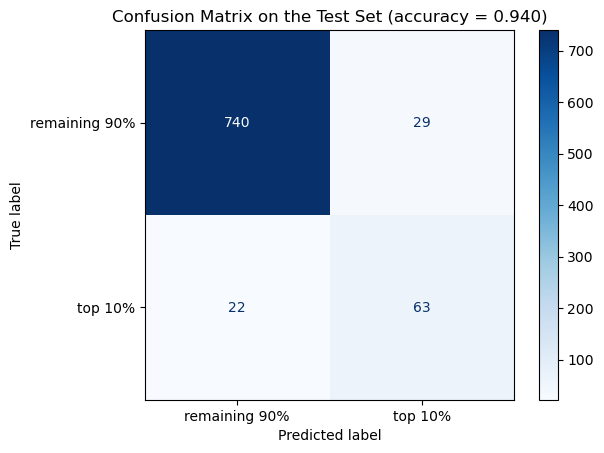

In [13]:
# Test set evaluation at threshold = 0.5

test_prob = elastic_net_logreg.predict_proba(X_test_S)[:, 1]
y_pred = (test_prob >= 0.5).astype(int)

final_test_results_df = pd.DataFrame(
    [
        {
            "model": "Elastic Net Logistic CV (buffer-filtered train)",
            "n_features": X_train_S.shape[1],
            "best_C": best_C,
            "best_l1_ratio": best_l1_ratio,
            "threshold": 0.5,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, test_prob),
            "TN": int(confusion_matrix(y_test, y_pred).ravel()[0]),
            "FP": int(confusion_matrix(y_test, y_pred).ravel()[1]),
            "FN": int(confusion_matrix(y_test, y_pred).ravel()[2]),
            "TP": int(confusion_matrix(y_test, y_pred).ravel()[3]),
            "threshold_type": "default_0.5"
        }
    ]
)

display(final_test_results_df)
print(classification_report(y_test, y_pred, target_names=["remaining 90%", "top 10%"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["remaining 90%", "top 10%"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix on the Test Set (accuracy = {accuracy_score(y_test, y_pred):.3f})")
plt.show()

---
## Selected features and their contribution

The elastic-net penalty shrinks most coefficients to zero, so the final model keeps only a small subset of the 2,447 input features.

Because all features were standardized before fitting, the coefficient sizes can be compared directly. Larger `|coef_i|` values mean that a feature has a stronger effect on the predicted log-odds of belonging to the top-10% class.

We summarize the selected features in two ways. First, we show a per-feature table with the coefficient sign, absolute size, and contribution percentage. Second, we group the selected features by category, such as assay-context, RDKit, MACCS, Morgan, and Tanimoto, to see whether the model is driven more by experimental context or by molecular features.

In [14]:
# Selected features only

coefs = pd.Series(
    elastic_net_logreg.coef_.ravel(),
    index=X_train_S.columns,
    name="coefficient",
)

selected = coefs[coefs != 0].copy()
total_abs = selected.abs().sum()

feature_summary = pd.DataFrame({"coefficient": selected})
feature_summary["abs_coefficient"] = feature_summary["coefficient"].abs()
feature_summary["contribution_pct"] = (feature_summary["abs_coefficient"] / total_abs * 100).round(2)
feature_summary = feature_summary.sort_values("abs_coefficient", ascending=False)
feature_summary["cumulative_pct"] = feature_summary["contribution_pct"].cumsum().round(2)


def category_of(name):
    if name.startswith("DMAX_AVE") or name.startswith("MIC_VALUE_uM") or name.startswith("CONC_VALUE_uM"):
        return "assay_numeric"
    if name.startswith("STRAIN_") or name.startswith("MIC_OPERATOR_"):
        return "assay_categorical"
    if name.startswith("rdkit_"):
        return "rdkit"
    if name.startswith("maccs_"):
        return "maccs"
    if name.startswith("morgan_"):
        return "morgan"
    if name.startswith("tan_"):
        return "tanimoto"
    return "other"


feature_summary["category"] = [category_of(name) for name in feature_summary.index]

feature_summary = feature_summary[["category", "coefficient", "abs_coefficient", "contribution_pct", "cumulative_pct"]]

display(feature_summary)

,category,coefficient,abs_coefficient,contribution_pct,cumulative_pct
DMAX_AVE,assay_numeric,0.836809,0.836809,82.34,82.34
tan_morgan_top10_count_ge_0_50,tanimoto,0.090633,0.090633,8.92,91.26
tan_morgan_top10_max,tanimoto,0.088874,0.088874,8.74,100.00


---

## Ablation checks

Before calling the final model done, I wanted to check where the performance is actually coming from.

Here I rerun the same Elastic Net Logistic RegressionCV setup with a few simpler feature sets:
- `DMAX_AVE` only
- full model without the Tanimoto similarity features
- full model without the buffer filtering step

This is mostly a sanity check. If the full model beats these simpler versions, then the extra feature engineering is doing something useful instead of just adding noise.

In [15]:
# Ablation checks with the same Elastic Net LogisticRegressionCV setup

ablation_rows = []


def run_ablation(name, X_table, train_rows):
    X_train_ab = X_table.loc[train_rows]
    X_test_ab = X_table.loc[test_idx]
    y_train_ab = y_top10.loc[train_rows]

    medians = X_train_ab.median()
    X_train_ab = X_train_ab.fillna(medians)
    X_test_ab = X_test_ab.fillna(medians)

    scaler = StandardScaler()
    X_train_ab = pd.DataFrame(
        scaler.fit_transform(X_train_ab),
        index=X_train_ab.index,
        columns=X_train_ab.columns
    )
    X_test_ab = pd.DataFrame(
        scaler.transform(X_test_ab),
        index=X_test_ab.index,
        columns=X_test_ab.columns
    )

    model = LogisticRegressionCV(
        Cs=model_Cs,
        cv=5,
        solver="saga",
        scoring="f1",
        class_weight="balanced",
        l1_ratios=model_l1_ratios,
        max_iter=5000,
        random_state=28,
        tol=0.001,
        n_jobs=-1
    )

    model.fit(X_train_ab, y_train_ab)

    test_prob_ab = model.predict_proba(X_test_ab)[:, 1]
    y_pred_ab = (test_prob_ab >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ab).ravel()

    ablation_rows.append(
        {
            "feature_set": name,
            "n_features": X_table.shape[1],
            "best_C": float(model.C_[0]),
            "best_l1_ratio": float(model.l1_ratio_[0]),
            "selected_features": int((model.coef_.ravel() != 0).sum()),
            "accuracy": accuracy_score(y_test, y_pred_ab),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_ab),
            "precision": precision_score(y_test, y_pred_ab, zero_division=0),
            "recall": recall_score(y_test, y_pred_ab, zero_division=0),
            "f1": f1_score(y_test, y_pred_ab, zero_division=0),
            "roc_auc": roc_auc_score(y_test, test_prob_ab),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        }
    )


# Same feature set as the final model
run_ablation("full model", X_full, train_model_idx_clean)

# Strong assay-derived signal by itself
run_ablation("DMAX_AVE only", X_full[["DMAX_AVE"]], train_model_idx_clean)

# Full feature set, but remove the engineered Tanimoto similarity features
no_tanimoto_cols = [c for c in X_full.columns if not c.startswith("tan_")]
run_ablation("without Tanimoto", X_full[no_tanimoto_cols], train_model_idx_clean)

# No buffer filter: rebuild Tanimoto references using all model-training rows
top10_idx_no_buffer = train_model_idx[y_top10.loc[train_model_idx].eq(1)].tolist()
remaining90_idx_no_buffer = train_model_idx[y_top10.loc[train_model_idx].eq(0)].tolist()

X_tanimoto_no_buffer = pd.concat(
    [
        tanimoto_features(morgan_fps, top10_idx_no_buffer, "tan_morgan_top10"),
        tanimoto_features(morgan_fps, remaining90_idx_no_buffer, "tan_morgan_remaining90"),
        tanimoto_features(maccs_fps, top10_idx_no_buffer, "tan_maccs_top10"),
        tanimoto_features(maccs_fps, remaining90_idx_no_buffer, "tan_maccs_remaining90"),
    ],
    axis=1
)

X_full_no_buffer = pd.concat([X_numeric, X_categorical, X_rdkit, X_maccs, X_morgan, X_tanimoto_no_buffer], axis=1)

run_ablation("no buffer filter", X_full_no_buffer, train_model_idx)

ablation_results = pd.DataFrame(ablation_rows).sort_values("f1", ascending=False).reset_index(drop=True)
ablation_results

/opt/anaconda3/envs/chem277a-project2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/opt/anaconda3/envs/chem277a-project2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated beha

,feature_set,n_features,best_C,best_l1_ratio,selected_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP
0,full model,2447,0.003,0.8,3,0.940281,0.851733,0.684783,0.741176,0.711864,0.949606,740,29,22,63
1,DMAX_AVE only,1,0.003,0.5,1,0.940281,0.825572,0.707317,0.682353,0.694611,0.906525,745,24,27,58
2,without Tanimoto,2427,0.003,0.5,17,0.939110,0.814457,0.708861,0.658824,0.682927,0.927553,746,23,29,56
3,no buffer filter,2447,0.003,0.8,3,0.928571,0.855695,0.613208,0.764706,0.680628,0.951931,728,41,20,65


## Conclusion

The final Elastic Net Logistic RegressionCV model worked best as an assay-aware top-10% inhibition classifier. On the test set, it reached `accuracy = 0.9403`, `balanced accuracy = 0.8517`, `precision = 0.6848`, `recall = 0.7412`, `F1 = 0.7119`, and `ROC-AUC = 0.9496`. Since the top-10% label is imbalanced, `recall`, `F1`, and `ROC-AUC` were more informative than accuracy alone.

The two selected Tanimoto features suggest that the model was not only using the assay-derived `DMAX_AVE` signal, but also learning whether a compound sits near an active chemical neighborhood. `tan_morgan_top10_max` captures the strongest Morgan fingerprint similarity to any top-10% inhibitor, while `tan_morgan_top10_count_ge_0_50` counts how many top-10% inhibitors are moderately similar to the compound. Their selection by Elastic Net suggests that structural similarity to known high-inhibition compounds added meaningful chemical context to the classifier.

The ablation results supported this overall, but with one interesting caveat. `DMAX_AVE` alone was already strong, but the full model still had better F1 and a better overall balance of precision and recall. Removing the Tanimoto features lowered performance, suggesting that the similarity features added useful chemical context. Removing the buffer filter actually resulted `recall = 0.7647`, which was surprising, but it also increased false positives and lowered precision/F1. So if recall were the only priority, the no-buffer model could be considered; however, for a more balanced screening model, the buffered full model was still the better choice.